In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [ ]:
print("1. Initializing Enterprise Scale Data Generation...")
#65 Godowns, 200 Products
godowns = pd.DataFrame({
    'godown_id': [f'GDN_{i:03d}' for i in range(65)],
    'locality_type': np.random.choice(['IT Tech Park', 'Residential', 'Commercial'], size=65)
})

products = pd.DataFrame({
    'product_id': [f'SKU_{i:03d}' for i in range(200)],
    'category': np.random.choice(['Groceries', 'Electronics', 'Skincare', 'Fresh Produce'], size=200)
})

1. Initializing Enterprise Scale Data Generation...


In [ ]:
# Generate 90 Days of Dates
start_date = pd.to_datetime('2023-01-01')
dates = pd.date_range(start=start_date, periods=90)
print(f"2. Simulating Orders for 65 Godowns and 200 Products over 90 days...")

# Create a massive cross-join of every godown, product, and date (1.17 Million Rows)
idx = pd.MultiIndex.from_product([dates, godowns['godown_id'], products['product_id']], names=['date', 'godown_id', 'product_id'])
df = pd.DataFrame(index=idx).reset_index()


2. Simulating Orders for 65 Godowns and 200 Products over 90 days...


In [ ]:
# Merge in metadata
df = pd.merge(df, godowns, on='godown_id')
df = pd.merge(df, products, on='product_id')

In [ ]:
# Vectorized simulation of 1.17 Million rows of demand (takes just 1 second!)
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'] >= 5
df['Weather_Rain'] = np.random.choice([0, 1], size=len(df), p=[0.8, 0.2]) # 20% chance of rain
df['is_promotion'] = np.where(df['date'].isin([pd.to_datetime('2023-02-15'), pd.to_datetime('2023-03-25')]), 1, 0)

In [ ]:
# Base demand + Random noise
df['daily_demand'] = np.random.poisson(lam=5, size=len(df))

In [ ]:
df['daily_demand'] = np.random.poisson(lam=5, size=len(df))
# Inject Business Rules at scale
df.loc[(df['locality_type'] == 'Residential') & (df['is_weekend']), 'daily_demand'] += 10 # Weekends in residential
df.loc[(df['Weather_Rain'] == 1) & (df['category'] == 'Groceries'), 'daily_demand'] += 8 # Groceries spike in rain
df.loc[df['is_promotion'] == 1, 'daily_demand'] *= 3 # Promo spikes
print(f"✅ Generated {len(df):,} rows of synthetic order data!")

✅ Generated 1,170,000 rows of synthetic order data!


In [ ]:
print("3. Feature Engineering...")

if 'daily_demand' not in df.columns:

    df['daily_demand'] = np.random.poisson(lam=5, size=len(df))
df.sort_values(by=['godown_id', 'product_id', 'date'], inplace=True)
df['rolling_7d_demand'] = df.groupby(['godown_id', 'product_id'])['daily_demand'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
df['lag_1d'] = df.groupby(['godown_id', 'product_id'])['daily_demand'].shift(1)
df['lag_7d'] = df.groupby(['godown_id', 'product_id'])['daily_demand'].shift(7)
df.fillna(0, inplace=True)

le_godown = LabelEncoder()
le_product = LabelEncoder()
df['godown_id_encoded'] = le_godown.fit_transform(df['godown_id'])
df['product_id_encoded'] = le_product.fit_transform(df['product_id'])

3. Feature Engineering...


In [ ]:
# Sort chronologically before split!
df.sort_values(by='date', inplace=True)
features = ['day_of_week', 'is_weekend', 'rolling_7d_demand', 'lag_1d', 'lag_7d', 'Weather_Rain', 'is_promotion', 'godown_id_encoded', 'product_id_encoded']
X = df[features]
y = df['daily_demand']

In [ ]:
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(f"4. Training XGBoost Model on {len(X_train):,} samples... (This might take ~15 seconds)")
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)


4. Training XGBoost Model on 936,000 samples... (This might take ~15 seconds)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print("5. Evaluating Model...")
preds = np.maximum(0, model.predict(X_test))
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
print(f"--- RESULTS ---")
print(f"RMSE: {rmse:.2f} units")
print(f"MAE: {mae:.2f} units")

5. Evaluating Model...
--- RESULTS ---
RMSE: 4.60 units
MAE: 2.45 units



6. Generating Visualizations...


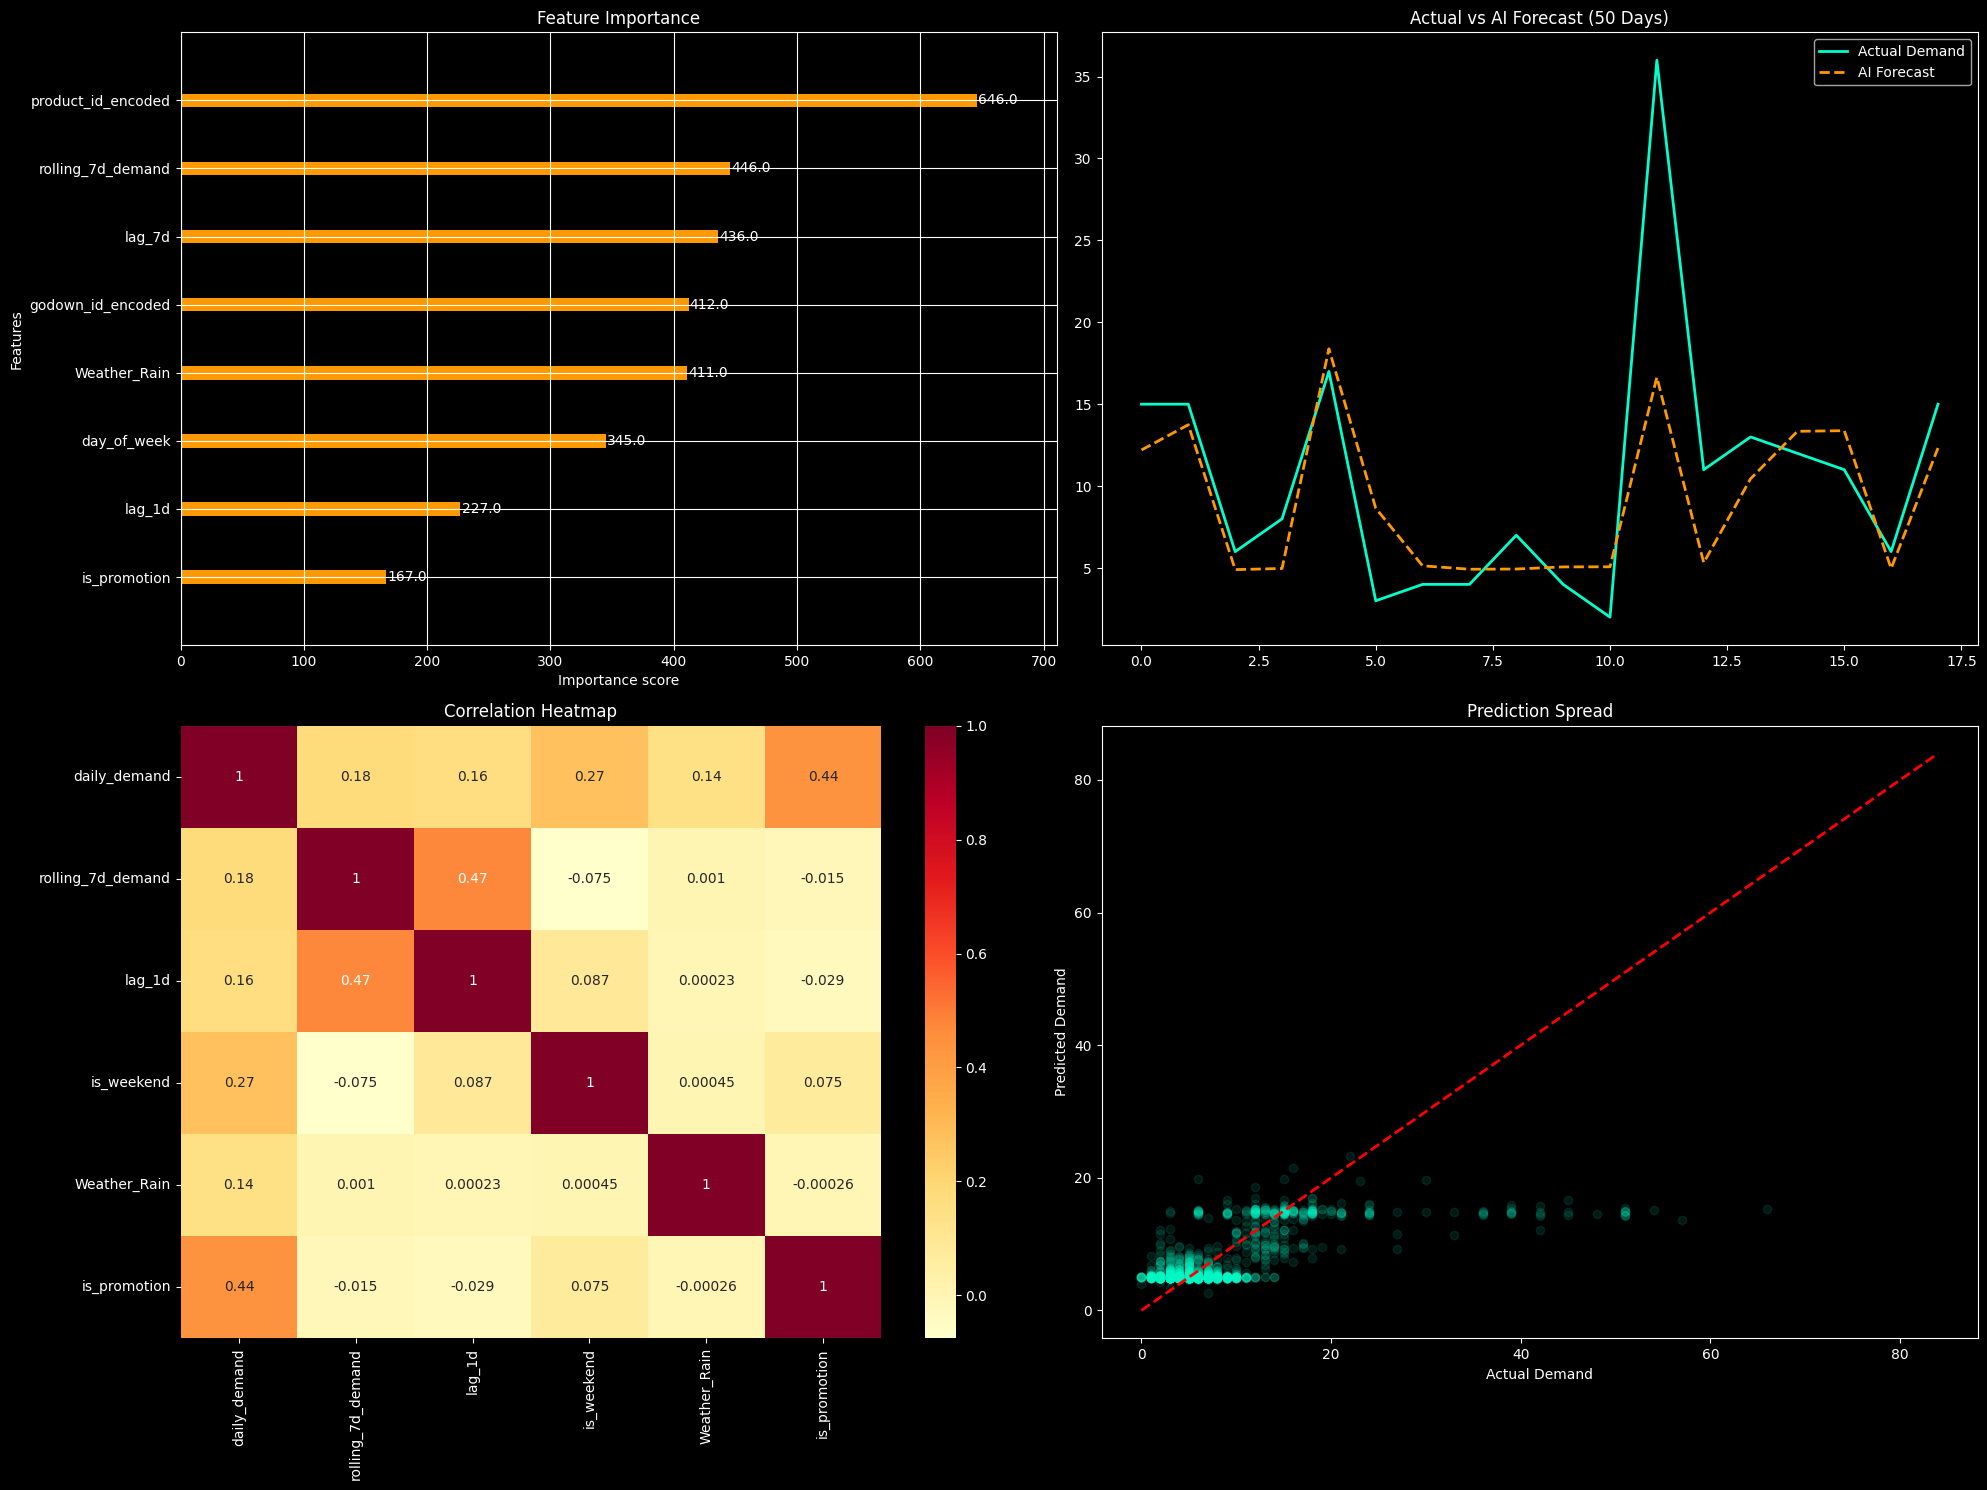

In [ ]:
print("\n6. Generating Visualizations...")
plt.style.use('dark_background')
fig = plt.figure(figsize=(20, 15))

ax1 = fig.add_subplot(221)
xgb.plot_importance(model, ax=ax1, title='Feature Importance', color='#FF9900')

ax2 = fig.add_subplot(222)
sample_mask = (X_test['product_id_encoded'] == 0) & (X_test['godown_id_encoded'] == 0)
ax2.plot(y_test[sample_mask].values[-50:], label='Actual Demand', color='#00ffcc', linewidth=2)
ax2.plot(preds[sample_mask][-50:], label='AI Forecast', color='#FF9900', linestyle='--', linewidth=2)
ax2.set_title('Actual vs AI Forecast (50 Days)')
ax2.legend()

ax3 = fig.add_subplot(223)
sns.heatmap(df[['daily_demand', 'rolling_7d_demand', 'lag_1d', 'is_weekend', 'Weather_Rain', 'is_promotion']].corr(), annot=True, cmap='YlOrRd', ax=ax3)
ax3.set_title('Correlation Heatmap')

ax4 = fig.add_subplot(224)
ax4.scatter(y_test[::100], preds[::100], alpha=0.1, color='#00ffcc') # Sample every 100th point to render fast
ax4.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax4.set_xlabel('Actual Demand')
ax4.set_ylabel('Predicted Demand')
ax4.set_title('Prediction Spread')

plt.tight_layout()
plt.show()